# Trabajo práctico 4: Aprendizaje No Supervisado

In [4]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys 
import os
sys.path.append(os.path.abspath("./src"))
sys.path.append(os.path.abspath("./data"))

import utils as utls 
import pca as pca
from collections import Counter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Inspección de Datos

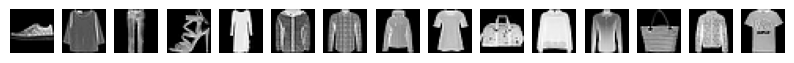

In [5]:
df = pd.read_csv("./data/fashion_mnist_subset.csv")

utls.plot_images(df, 15)
#Ver de hacer las fotos mas grandes


In [6]:
print(df.shape)
print(df.head())

# Separar features y etiquetas
# Asumiendo que la última columna es la etiqueta
X = df.iloc[:, :-1].values  # píxeles
y = df.iloc[:, -1].values   # etiquetas

(25000, 785)
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0   0.0039   0.0000   
1      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
2      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
3      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0627   
4      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   

   pixel_8  pixel_9  ...  pixel_775  pixel_776  pixel_777  pixel_778  \
0   0.0196   0.0902  ...     0.1647     0.0000     0.0000     0.0000   
1   0.0000   0.0000  ...     0.0000     0.0000     0.0000     0.0000   
2   0.0000   0.0000  ...     0.4235     0.2157     0.0000     0.0000   
3   0.2078   0.0000  ...     0.0549     0.0000     0.1529     0.3843   
4   0.0000   0.0000  ...     0.0000     0.0000     0.0078     0.0000   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  label  
0     0.0000        0.0  

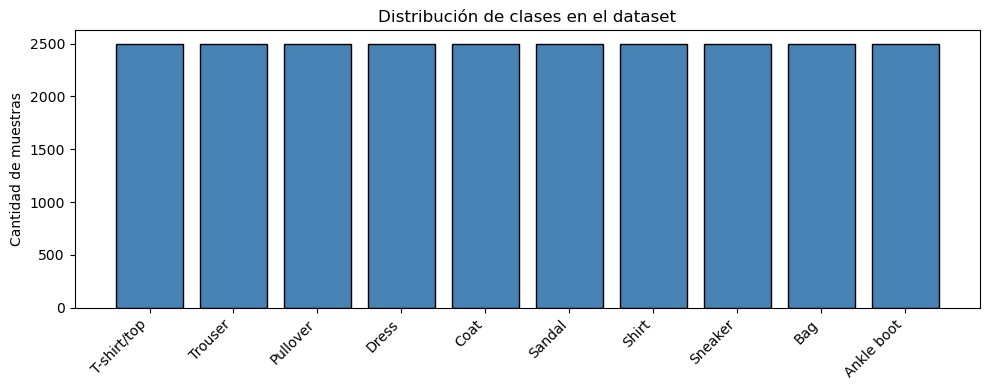

In [7]:
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

class_counts = Counter(y)
classes, counts = zip(*sorted(class_counts.items()))
labels = [class_names[c] for c in classes]

utls.barplot(labels, counts)

El dataset esta completamente balanceado, todas las clases tienen 2500 muestras. Esto significa que no hay riesgo de sesgos en el entrenamiento hacia ninguna clase en particular.

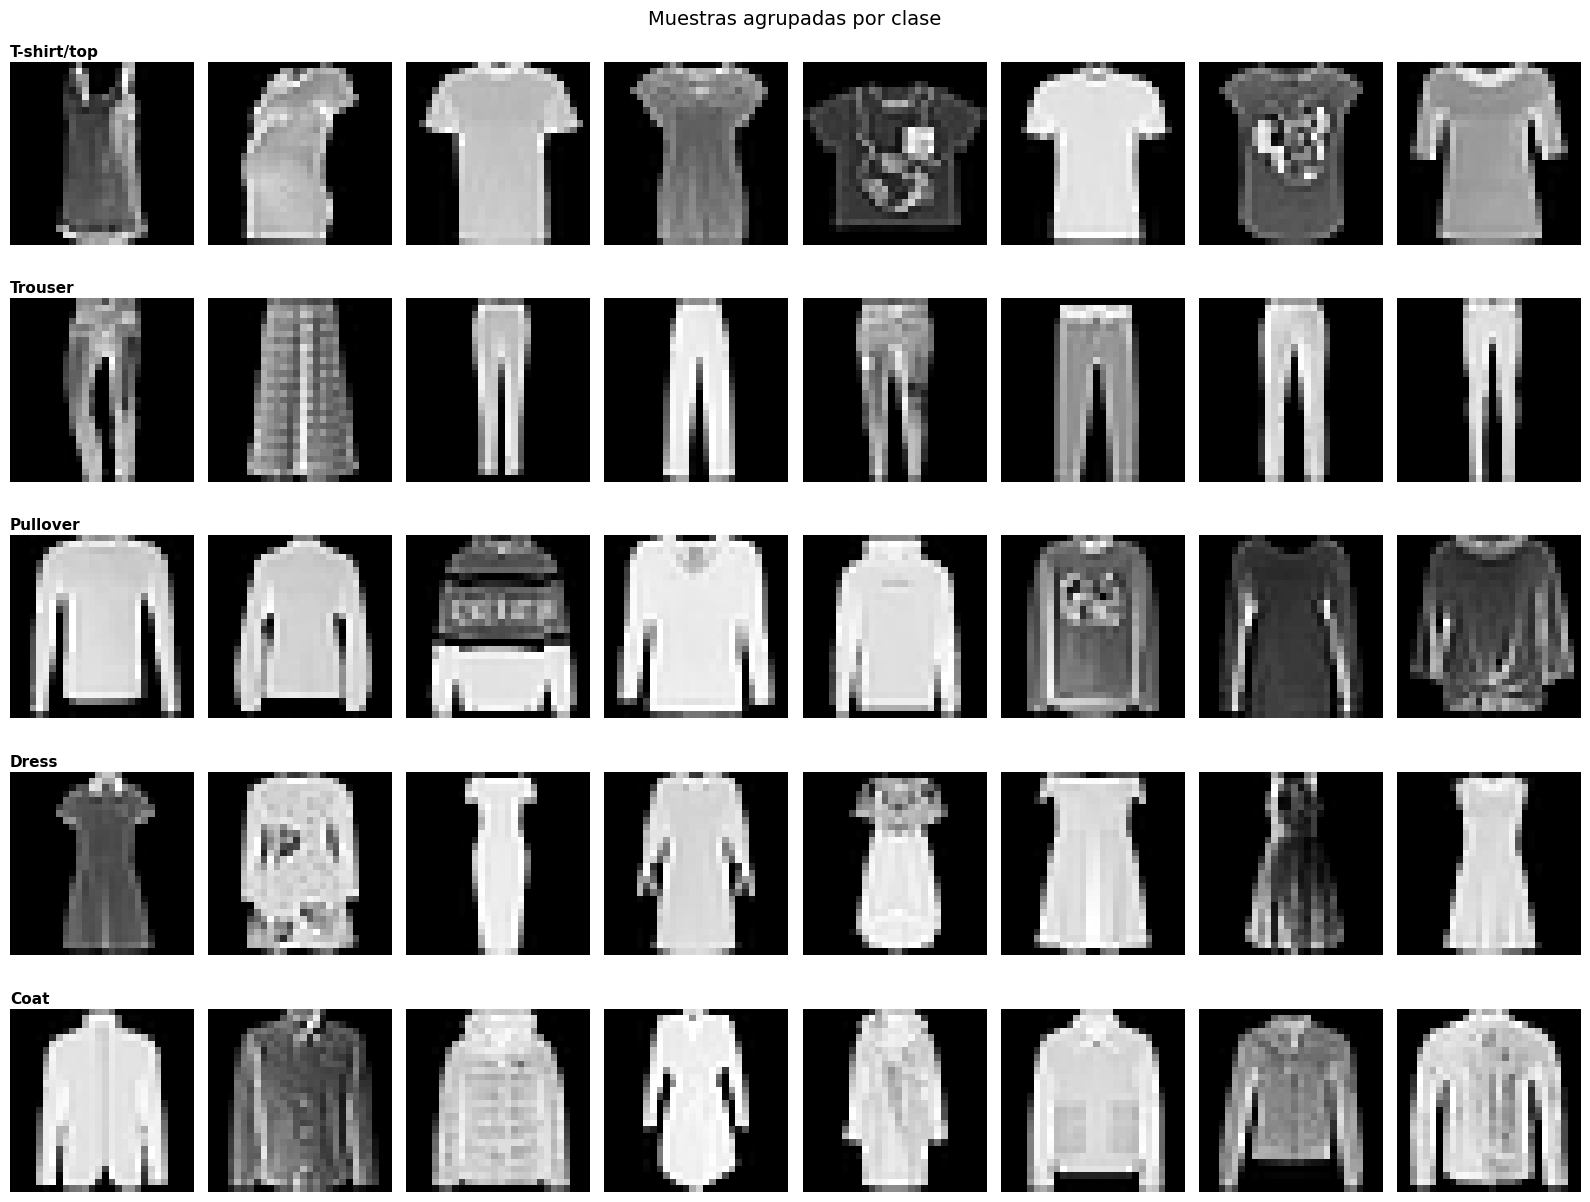

In [8]:
# Llamar la función con 5 clases y 8 muestras por clase
utls.plot_samples_by_class(X, y, class_names, n_samples=8,
                      classes_to_show=[0, 1, 2, 3, 4])

Se puede ver que dentro de las clases propias, la muestras varian mucho entre ellas, ya sea en color, estampado, largo o textura.

Tambien algunas clases pueden confundirse entre si por similitudes en los disenos, como vestidos, tapados y pullovers. Esto significa que los modelos de aprendizaje no supervisado podrian llegar a confundir estas clases.


### Split de Train/Test

In [9]:
# Split estratificado: cada subconjunto debe mantener la misma proporcion de clases que el dataset original

X_train, X_test, y_train, y_test = utls.stratified_split(X, y, test_size=0.2)



## 2. Reduccion de Dimensionalidad

In [12]:
# 1. Estandarizar
X_train_std, X_test_std, media, desvio = utls.standarization(X_train, X_test)

# 2. Aprender PCA sobre train para ver varianza
eigenvalues, eigenvectors = pca.pca_fit(X_train_std)

varianza_explicada = eigenvalues / np.sum(eigenvalues)
varianza_acumulada = np.cumsum(varianza_explicada)

# 4. Elegir K componentes que expliquen el 90%
K = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes para 90% de varianza: {K}")

# 5. Transformar train y test con K componentes
_, eigenvectors_K = pca.pca_fit(X_train_std, n_components=K)
X_train_pca = pca.pca_transform(X_train_std, eigenvectors_K)
X_test_pca  = pca.pca_transform(X_test_std,  eigenvectors_K)

Componentes para 90% de varianza: 135


Gracias a la reduccion de PCA, se puede identificar que 135 componentes son suficientes para capturar el 90% de la varianza de los datos, y por ende se puede descartar el 10% restante. Esto es porque al realizar la reconstruccion de los datos con estas 135 componentes de mayor varianza, se conserva el 90% de la informacion del dataset. 